In [1]:
import numpy as np
import pickle
import os
import re 
import json 
import click
import torch
import dnnlib.util_v4 as util
from torch_utils import distributed as dist
from training import toy_training_loop_vfm_noDataGen
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from plot_neural import *
from plot_sim_results import * 

import warnings
warnings.filterwarnings('ignore', 'Grad strides do not match bucket view strides') # False warning 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)

# 1. Read Data

In [2]:
folder_data = 'data/mc_maze'
dataset_samples = np.load(folder_data + "/dataset_samples.npz", allow_pickle=True)
data_raw = dataset_samples['samples']
dset_samples = []
for ii in range(len(data_raw)):
    dset_samples.append(np.asarray(data_raw[ii], dtype=np.float64))

In [3]:
print(len(dset_samples))
print(dset_samples[0].shape)

592
(2997, 137)


In [4]:
# corresponding meta data
train_meta = np.load(folder_data + "/meta_train.npy", allow_pickle=True).tolist()
trial_idx_use = np.array(train_meta['trial_info']['trial_version']) == 0
np.sum(trial_idx_use)

592

In [5]:
train_meta['trial_info'].keys()

dict_keys(['trial_type', 'start_time', 'stop_time', 'trial_version', 'maze_id', 'success', 'target_on_time', 'go_cue_time', 'move_onset_time', 'rt', 'delay', 'num_targets', 'target_pos', 'num_barriers', 'barrier_pos', 'active_target'])

In [6]:
trial_type_use = np.array(train_meta['trial_info']['trial_type'])[trial_idx_use]

# 2. PCA trial type by type

In [9]:
trial_type_use_unique = np.unique(trial_type_use)
explained_var_list = []
explained_var_ratio_list = []
transform_list = []
dset_samples_sel_list = []

for ii in tqdm(range(len(trial_type_use_unique))):
    choose_idx = trial_type_use == trial_type_use_unique[ii]
    dset_samples_sel = [dset_samples[idx] for idx in np.where(choose_idx)[0]]
    mean, components, explained_var, explained_var_ratio, transform = pca_stream(dset_samples_sel,
                                                                                 n_components=None)
    # to save
    explained_var_list.append(explained_var)
    explained_var_ratio_list.append(explained_var_ratio)
    transform_list.append(transform)
    dset_samples_sel_list.append(dset_samples_sel)

100%|███████████████████████████████████████████| 36/36 [00:00<00:00, 50.25it/s]


In [10]:
type_plot = trial_type_use_unique[0]

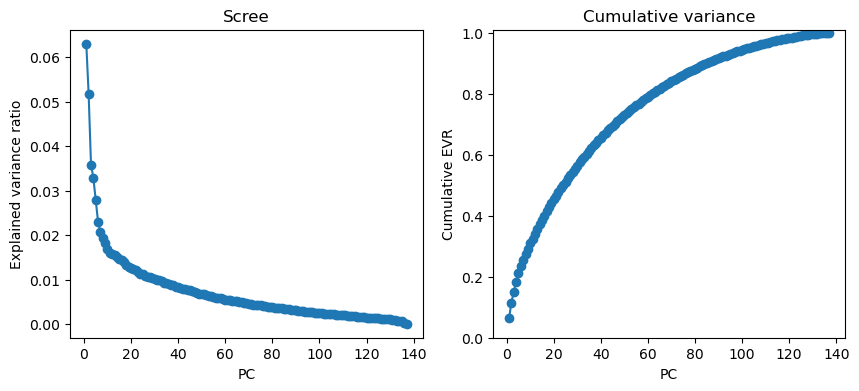

In [11]:
plot_scree(explained_var_list[type_plot], explained_var_ratio_list[type_plot])

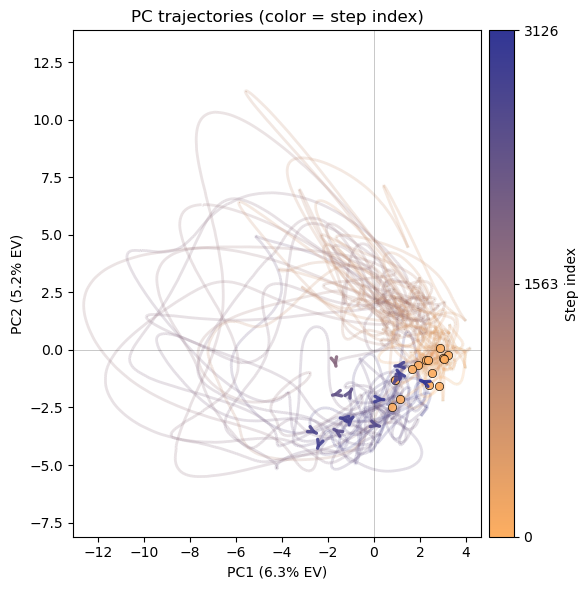

In [12]:
plot_trial_trajectories_gradient_steps(
    transform_list[type_plot],
    dset_samples_sel_list[type_plot],
    trial_indices=np.arange(len(dset_samples_sel_list[type_plot])),   # or any subset
    comps=(0, 1),
    evr=explained_var_ratio_list[type_plot],
    linewidth=2.0,
    start_marker_size=36,
    alpha=0.2,
    start_marker_alpha=0.9,
    end_arrow_alpha=0.9,
    fig_w = 6, fig_h = 6
)

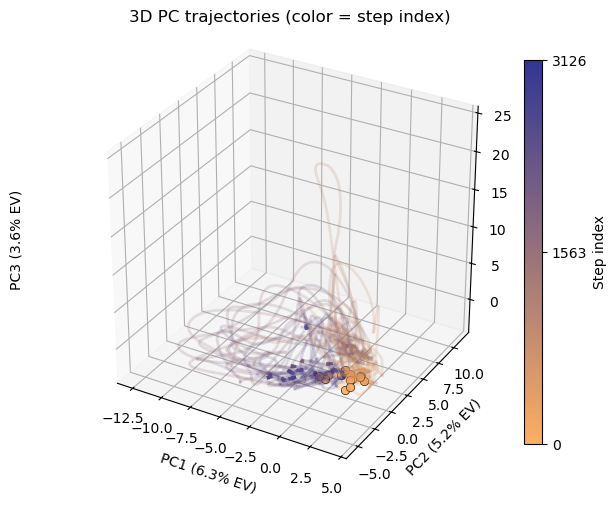

In [13]:
plot_trial_trajectories_gradient_steps_3d(
    transform_list[type_plot],
    dset_samples_sel_list[type_plot],
    trial_indices=np.arange(len(dset_samples_sel_list[type_plot])),  # or choose a subset
    comps=(0, 1, 2),
    evr=explained_var_ratio_list[type_plot],
    start_marker_alpha=0.9,
    end_arrow_alpha=0.9,
    alpha = 0.2
)